# Dynamic Window Dataset and EDA

Explore the pre-built window-level dynamic emotion dataset, extract per-window spectral features, and visualize emotion trajectories over time.

**Input:** `data/processed/dynamic_windows.csv` (from notebook 01), DEAM metadata, dynamic annotations  
**Outputs:**
- `data/features/dynamic_window_features.csv`
- `reports/tables/dynamic_emotion_change_summary.csv`
- `reports/figures/dynamic_trajectories/`

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "configs").exists() and (PROJECT_ROOT.parent / "configs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_project_root, load_configs, resolve_path
from src.data.load_deam import build_metadata_table, load_dynamic_annotations
from src.data.make_dynamic_dataset import (
    build_dynamic_trajectory_summary,
    load_dynamic_windows,
    save_dynamic_trajectory_summary,
)
from src.features.dynamic_window_features import (
    extract_dynamic_window_features_dataset,
    load_dynamic_window_features,
    save_dynamic_window_features,
)
from src.visualization.emotion_trajectories import (
    plot_emotion_quadrant_over_time,
    plot_emotion_trajectory_2d,
    plot_example_trajectories,
    plot_valence_arousal_over_time,
)

configs = load_configs(PROJECT_ROOT)
root = get_project_root(PROJECT_ROOT)
sns.set_theme(style="whitegrid")

## 1. Load metadata and dynamic annotations

In [3]:
metadata = build_metadata_table(configs)
dynamic_df = load_dynamic_annotations(configs)

print(f"Metadata tracks: {len(metadata)}")
print(f"Complete tracks: {metadata['is_complete'].sum()}")
print(f"Dynamic annotation rows: {len(dynamic_df)}")
print(f"Dynamic tracks: {dynamic_df['song_id'].nunique()}")

Scanning audio files:   0%|          | 0/1802 [00:00<?, ?it/s]

Metadata tracks: 1802
Complete tracks: 1802
Dynamic annotation rows: 129995
Dynamic tracks: 1802


## 2. Load dynamic window dataset

In [5]:
windows_csv = resolve_path(root, configs["paths"]["processed"]["dynamic_windows_csv"])
windows_parquet = resolve_path(root, configs["paths"]["processed"]["dynamic_windows"])
dynamic_windows = load_dynamic_windows(configs, attach_splits=True, save=True)

source = windows_parquet if windows_parquet.exists() else windows_csv
print(f"Loaded from: {source}")
print(f"Tracks with windows: {dynamic_windows['song_id'].nunique()}")
print(f"Total windows: {len(dynamic_windows)}")
print("No window leakage detected.")
dynamic_windows.head()

Loaded from: C:\Users\athen\Desktop\music-emotion-recognition\data\processed\dynamic_windows.parquet
Tracks with windows: 1802
Total windows: 129995
No window leakage detected.


,song_id,window_start_sec,window_end_sec,window_index,valence,arousal,dynamic_emotion_quadrant,dynamic_emotion_class,valence_threshold,arousal_threshold,split,annotation_time_sec
0,2,14.5,15.5,29,-0.073341,-0.109386,Q4,low_valence_low_arousal,0.095,0.133338,train,15.0
1,2,15.0,16.0,30,-0.074001,-0.112164,Q4,low_valence_low_arousal,0.095,0.133338,train,15.5
2,2,15.5,16.5,31,-0.074369,-0.115677,Q4,low_valence_low_arousal,0.095,0.133338,train,16.0
3,2,16.0,17.0,32,-0.076115,-0.117513,Q4,low_valence_low_arousal,0.095,0.133338,train,16.5
4,2,16.5,17.5,33,-0.079871,-0.122535,Q4,low_valence_low_arousal,0.095,0.133338,train,17.0


In [6]:
dynamic_windows["split"].value_counts()

split
train    94725
val      17952
test     17318
Name: count, dtype: int64

## 3. Dynamic emotion quadrant distribution

In [7]:
quadrant_counts = dynamic_windows["dynamic_emotion_quadrant"].value_counts().sort_index()
quadrant_summary = quadrant_counts.rename("count").to_frame()
quadrant_summary["proportion"] = quadrant_summary["count"] / quadrant_summary["count"].sum()
quadrant_summary

,count,proportion
dynamic_emotion_quadrant,,
Q1,44834,0.344890
Q2,20274,0.155960
Q3,20134,0.154883
Q4,44753,0.344267


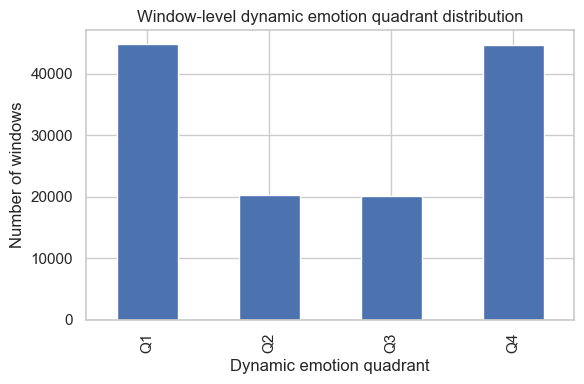

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
quadrant_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Dynamic emotion quadrant")
ax.set_ylabel("Number of windows")
ax.set_title("Window-level dynamic emotion quadrant distribution")
fig.tight_layout()
plt.show()

## 4. Per-track emotion change summary

In [9]:
change_summary = build_dynamic_trajectory_summary(dynamic_df, dynamic_windows, configs)
saved_summary = save_dynamic_trajectory_summary(change_summary, configs)

print(f"Emotionally stable tracks: {change_summary['is_emotionally_stable'].sum()}")
print(f"Emotionally changing tracks: {change_summary['is_emotionally_changing'].sum()}")
print(f"Saved to: {saved_summary['csv']}")
change_summary.head()

Emotionally stable tracks: 1270
Emotionally changing tracks: 532
Saved to: C:\Users\athen\Desktop\music-emotion-recognition\reports\tables\dynamic_emotion_change_summary.csv


,song_id,n_samples,n_quadrant_transitions,is_emotionally_stable,is_emotionally_changing,dominant_emotion_quadrant,dominant_emotion_class,pct_time_Q1,pct_time_Q2,pct_time_Q3,pct_time_Q4,split,track_id,n_transitions,is_stable,dominant_quadrant
0,2,60,0,True,False,Q4,low_valence_low_arousal,0.0,0.0,0.0,100.0,train,2,0,True,Q4
1,3,60,0,True,False,Q4,low_valence_low_arousal,0.0,0.0,0.0,100.0,train,3,0,True,Q4
2,4,60,6,False,True,Q1,high_valence_high_arousal,85.0,0.0,15.0,0.0,train,4,6,False,Q1
3,5,60,0,True,False,Q2,high_valence_low_arousal,0.0,100.0,0.0,0.0,val,5,0,True,Q2
4,7,60,0,True,False,Q1,high_valence_high_arousal,100.0,0.0,0.0,0.0,val,7,0,True,Q1


## 5. Example stable vs changing tracks

In [10]:
stable_examples = (
    change_summary.loc[change_summary["is_emotionally_stable"], "song_id"]
    .head(3)
    .tolist()
)
changing_examples = (
    change_summary.loc[change_summary["is_emotionally_changing"]]
    .sort_values("n_quadrant_transitions", ascending=False)["song_id"]
    .head(3)
    .tolist()
)

print("Stable example tracks:", stable_examples)
print("Changing example tracks:", changing_examples)

change_summary.loc[
    change_summary["song_id"].isin(stable_examples + changing_examples),
    ["song_id", "n_quadrant_transitions", "dominant_emotion_quadrant", "is_emotionally_stable"],
]

Stable example tracks: [2, 3, 5]
Changing example tracks: [2055, 2007, 2004]


,song_id,n_quadrant_transitions,dominant_emotion_quadrant,is_emotionally_stable
0,2,0,Q4,True
1,3,0,Q4,True
3,5,0,Q2,True
1747,2004,43,Q1,False
1750,2007,50,Q4,False
1798,2055,62,Q4,False


## 6. Extract dynamic window features

In [11]:
features_path = resolve_path(root, configs["paths"]["features"]["dynamic_window_features_csv"])

if features_path.exists():
    window_features = load_dynamic_window_features(configs)
    print(f"Loaded existing features from {features_path}")
else:
    window_features = extract_dynamic_window_features_dataset(dynamic_windows, metadata, configs)
    saved_features = save_dynamic_window_features(window_features, configs)
    print(f"Saved features to {saved_features['csv']}")

print(f"Feature matrix shape: {window_features.shape}")
window_features.head()

Extracting window features:   0%|          | 0/1802 [00:00<?, ?it/s]

c:\Users\athen\miniconda3\envs\music-emotion-recognition\lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Saved features to C:\Users\athen\Desktop\music-emotion-recognition\data\features\dynamic_window_features.csv
Feature matrix shape: (129995, 187)


,song_id,window_index,chroma_10_max,chroma_10_mean,chroma_10_median,chroma_10_min,chroma_10_std,chroma_11_max,chroma_11_mean,chroma_11_median,...,spectral_rolloff_1_max,spectral_rolloff_1_mean,spectral_rolloff_1_median,spectral_rolloff_1_min,spectral_rolloff_1_std,zcr_1_max,zcr_1_mean,zcr_1_median,zcr_1_min,zcr_1_std
0,2,29,1.000000,0.400101,0.244878,0.045623,0.367475,1.000000,0.444867,0.330966,...,7138.256836,4731.431996,4306.640625,2777.783203,1286.242210,0.165527,0.070945,0.063477,0.007812,0.033821
1,2,30,0.826409,0.180366,0.111383,0.045786,0.168157,0.809836,0.121605,0.060542,...,6901.391602,3925.160356,3509.912109,2422.485352,1213.211468,0.165527,0.067305,0.058838,0.028320,0.028985
2,2,31,0.633011,0.165807,0.100149,0.041012,0.157228,0.361943,0.071396,0.056877,...,5512.500000,3593.353271,3337.646484,2476.318359,911.564599,0.081055,0.054854,0.052734,0.032715,0.011636
3,2,32,0.331746,0.092462,0.076676,0.025364,0.057898,0.228074,0.072342,0.061264,...,5652.465820,3762.927246,3709.094238,2293.286133,948.898823,0.101074,0.064708,0.063965,0.023438,0.018724
4,2,33,0.438250,0.132571,0.115288,0.029199,0.077278,0.294128,0.071130,0.054987,...,6276.928711,3535.605136,3375.329590,2336.352539,936.492415,0.100098,0.071822,0.076416,0.035645,0.016749


## 7. Plot emotion trajectories for example tracks

song_id=2: {'valence_arousal': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/reports/figures/dynamic_trajectories/song_2_valence_arousal.png'), 'quadrant': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/reports/figures/dynamic_trajectories/song_2_quadrant_over_time.png'), 'trajectory_2d': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/reports/figures/dynamic_trajectories/song_2_trajectory_2d.png')}
song_id=3: {'valence_arousal': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/reports/figures/dynamic_trajectories/song_3_valence_arousal.png'), 'quadrant': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/reports/figures/dynamic_trajectories/song_3_quadrant_over_time.png'), 'trajectory_2d': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/reports/figures/dynamic_trajectories/song_3_trajectory_2d.png')}
song_id=2055: {'valence_arousal': WindowsPath('C:/Users/athen/Desktop/music-emotion-recognition/reports/

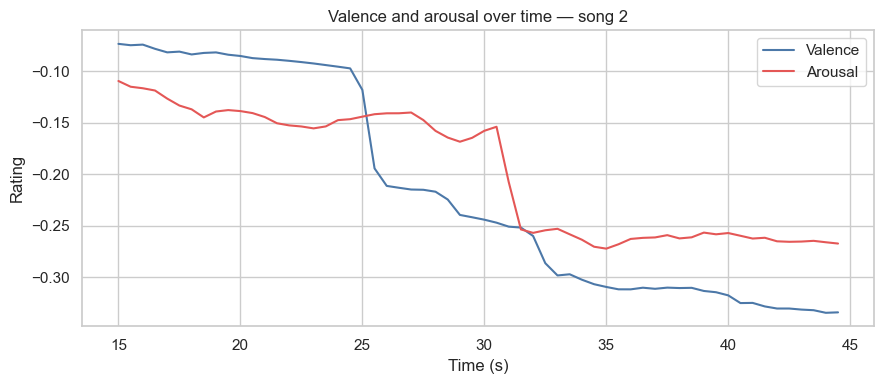

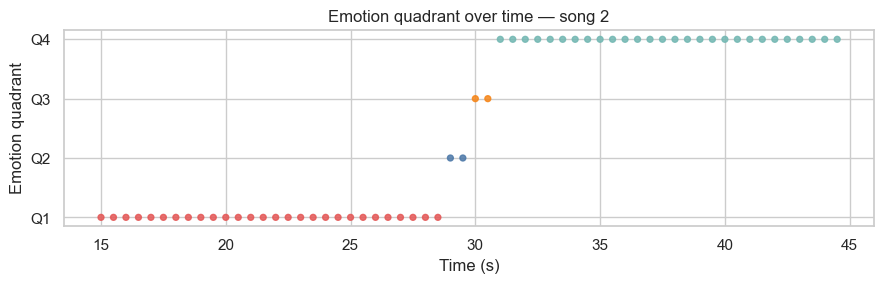

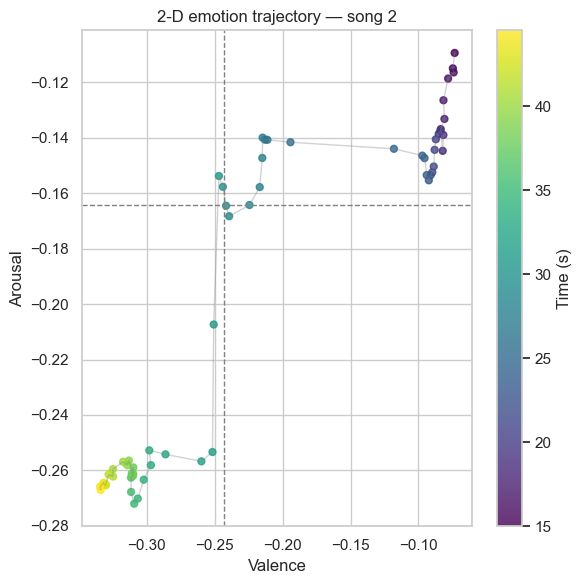

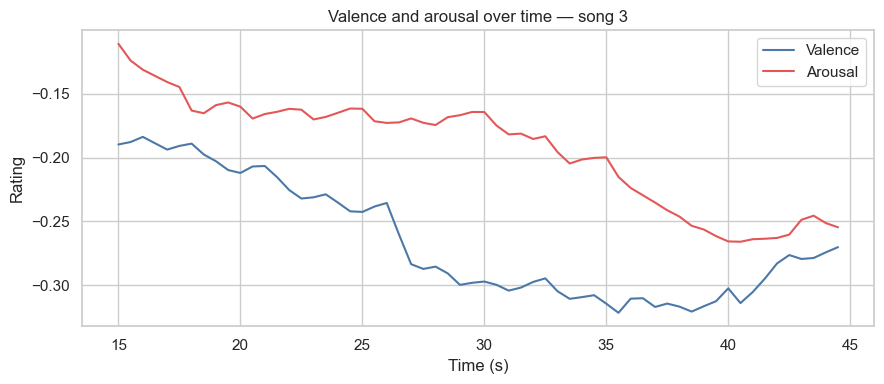

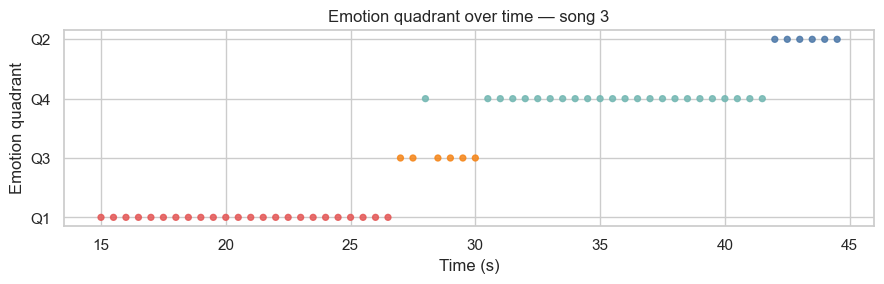

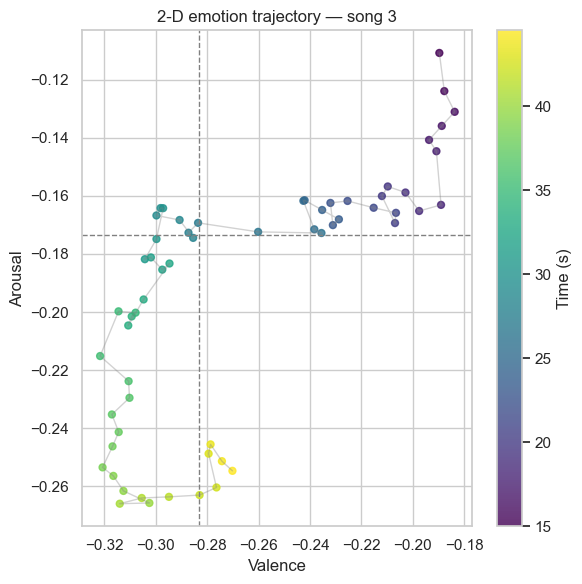

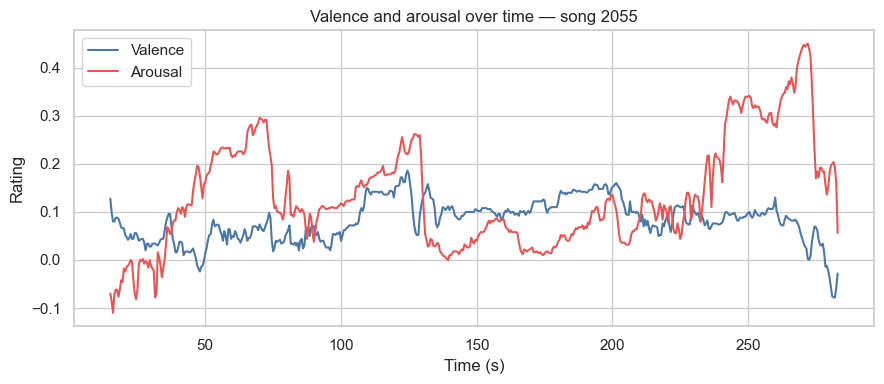

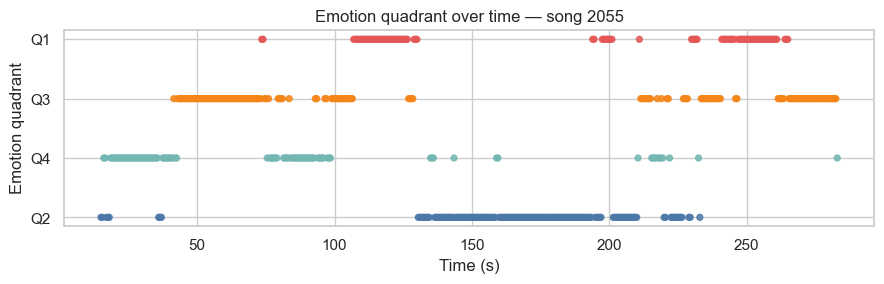

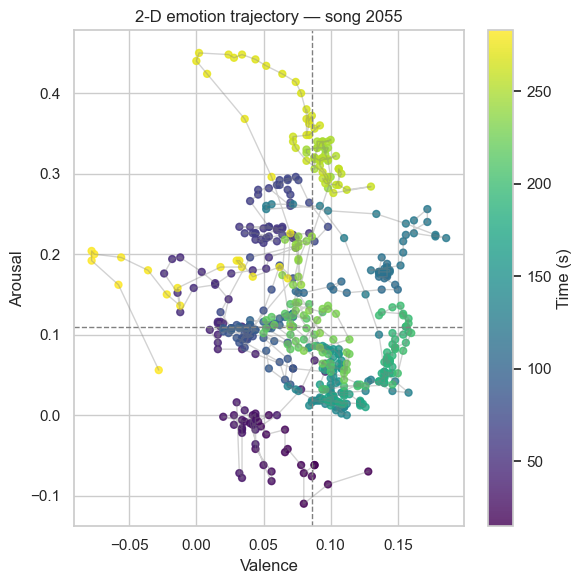

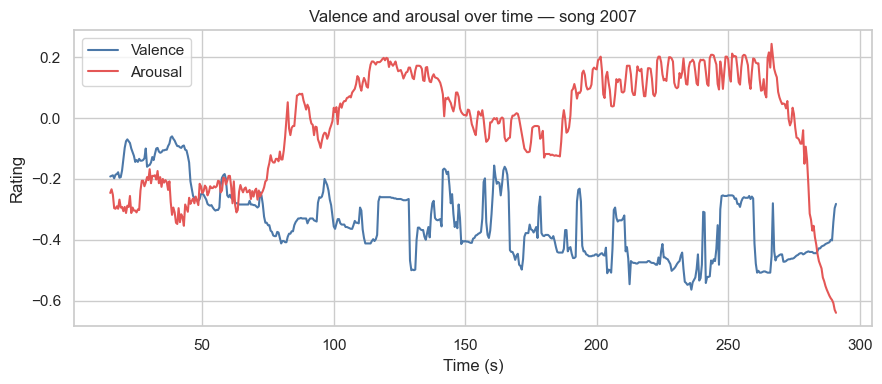

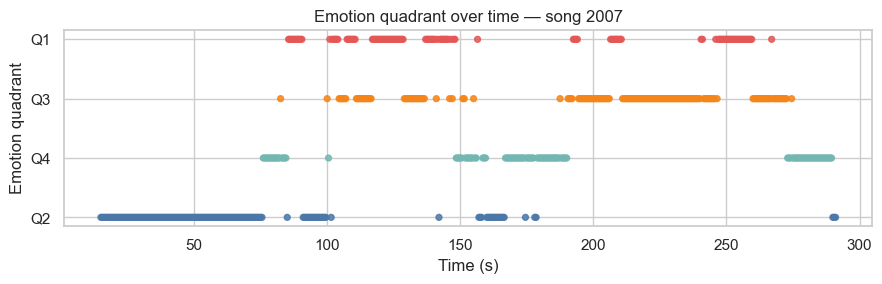

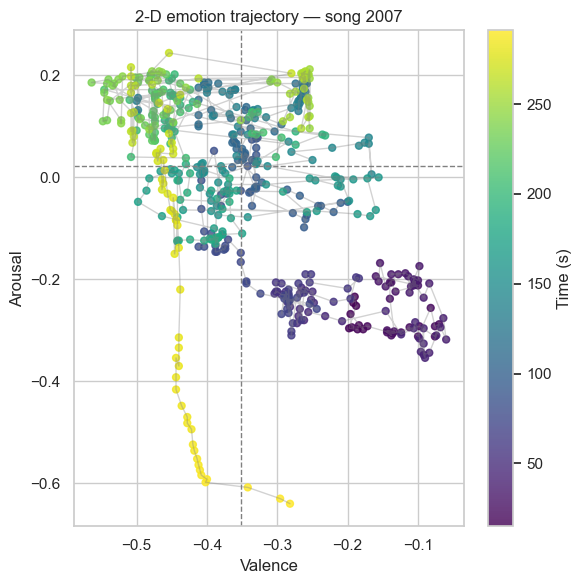

In [12]:
example_songs = stable_examples[:2] + changing_examples[:2]
figures_dir = resolve_path(root, configs["paths"]["reports"]["dynamic_trajectories"])
saved_plots = plot_example_trajectories(example_songs, dynamic_df, configs)

for song_id, paths in saved_plots.items():
    print(f"song_id={song_id}: {paths}")

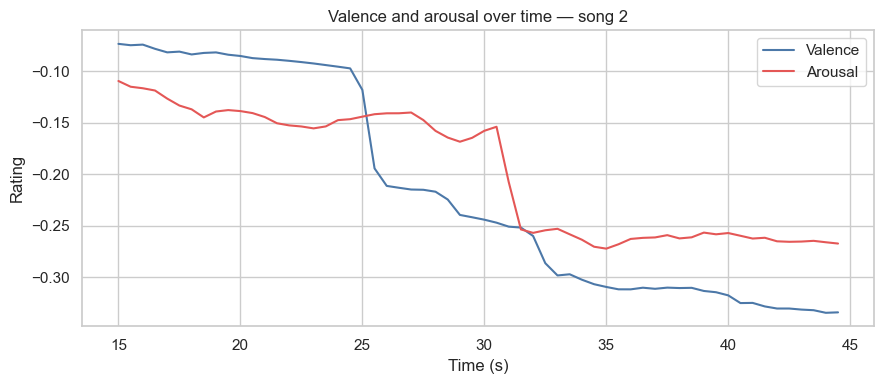

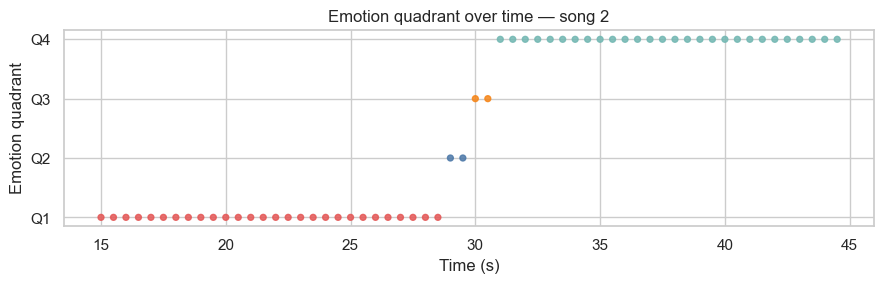

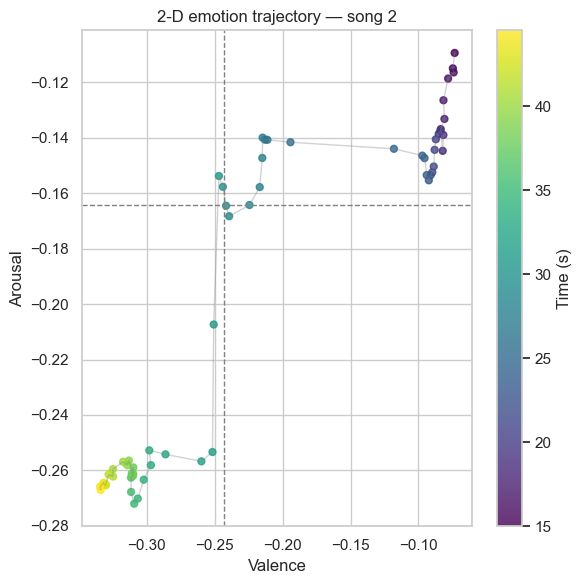

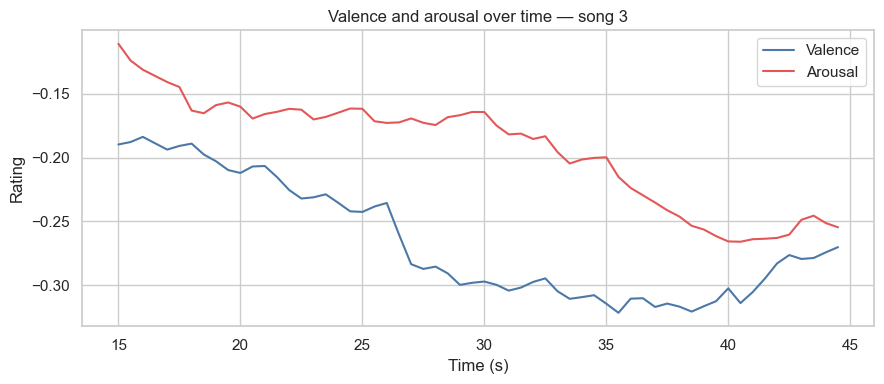

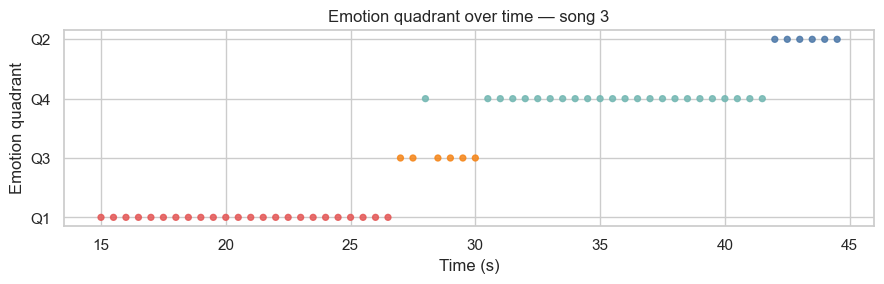

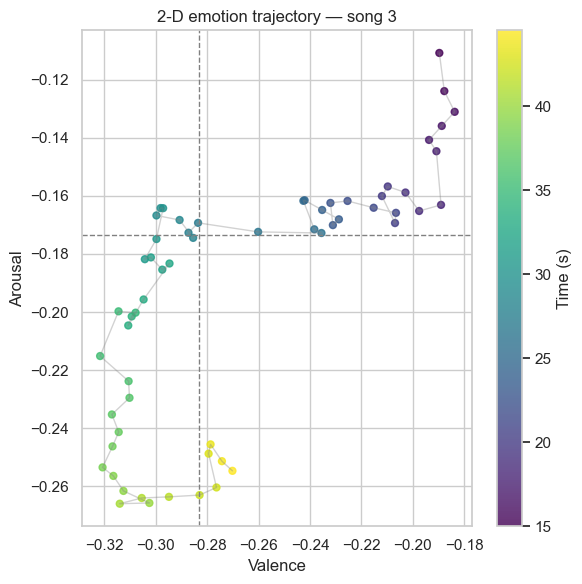

In [13]:
for song_id in example_songs[:2]:
    plot_valence_arousal_over_time(song_id, dynamic_df, configs)
    plot_emotion_quadrant_over_time(song_id, dynamic_df, configs)
    plot_emotion_trajectory_2d(song_id, dynamic_df, configs)
    plt.show()